# BirdCLEF 2026: EDA

Этот notebook нужен, чтобы понять датасет до улучшения модели: сколько классов, какие классы редкие, какие группы животных есть, насколько важны размеченные soundscape-сегменты.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

os.environ.setdefault(
    "BC2026_DATA_DIR",
    "/Users/kseniadragun/Desktop/Predictive_Analytics/birds /birdclef-2026",
)

data_dir = Path(os.environ["BC2026_DATA_DIR"])
print(data_dir)

/Users/kseniadragun/Desktop/Predictive_Analytics/birds /birdclef-2026


## 1. Загружаем таблицы

In [2]:
train = pd.read_csv(data_dir / "train.csv")
taxonomy = pd.read_csv(data_dir / "taxonomy.csv")
sample = pd.read_csv(data_dir / "sample_submission.csv")
soundscape_labels = pd.read_csv(data_dir / "train_soundscapes_labels.csv")

print(f"train rows: {len(train):,}")
print(f"taxonomy rows: {len(taxonomy):,}")
print(f"submission classes: {len(sample.columns) - 1:,}")
print(f"labeled soundscape segments: {len(soundscape_labels):,}")

train rows: 35,549
taxonomy rows: 234
submission classes: 234
labeled soundscape segments: 1,478


In [3]:
train.head()

,primary_label,secondary_labels,type,latitude,longitude,scientific_name,common_name,class_name,inat_taxon_id,author,license,rating,url,filename,collection
0,1161364,[],[],-22.7562,-46.8666,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1216197....,1161364/iNat1216197.ogg,iNat
1,1161364,[],[],-22.7558,-46.8700,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/1114648....,1161364/iNat1114648.ogg,iNat
2,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/810195.m...,1161364/iNat810195.ogg,iNat
3,1161364,[],[],-22.7547,-46.8728,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/818781.m...,1161364/iNat818781.ogg,iNat
4,1161364,[],[],-22.7426,-46.8985,Guyalna cuta,Guyalna cuta,Insecta,1161364,Lucas Barbosa,cc-by-nc,0.0,https://static.inaturalist.org/sounds/556514.m...,1161364/iNat556514.ogg,iNat


## 2. Какие классы животных есть в соревновании

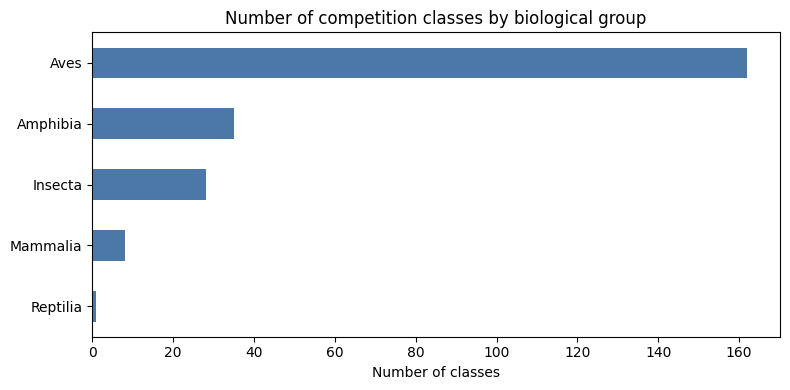

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64

In [4]:
class_counts = taxonomy["class_name"].value_counts().sort_values(ascending=True)

ax = class_counts.plot(kind="barh", figsize=(8, 4), color="#4C78A8")
ax.set_title("Number of competition classes by biological group")
ax.set_xlabel("Number of classes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

class_counts.sort_values(ascending=False)

## 3. Дисбаланс классов в train_audio

Это важно: модель легче учит классы, где сотни записей, и плохо видит редкие классы, где 1-5 записей.

In [5]:
label_counts = train["primary_label"].value_counts()

print("Most common labels")
display(label_counts.head(20).to_frame("count"))

print("Rarest labels")
display(label_counts.tail(20).to_frame("count"))

Most common labels


,count
primary_label,
rubthr1,499
banana,498
soulap1,497
fepowl,497
houspa,496
osprey,495
coffal1,495
socfly1,494
compau,493


Rarest labels


,count
primary_label,
22985,6
22961,6
23154,5
1595929,5
66971,5
738183,5
23176,4
64898,3
74580,3


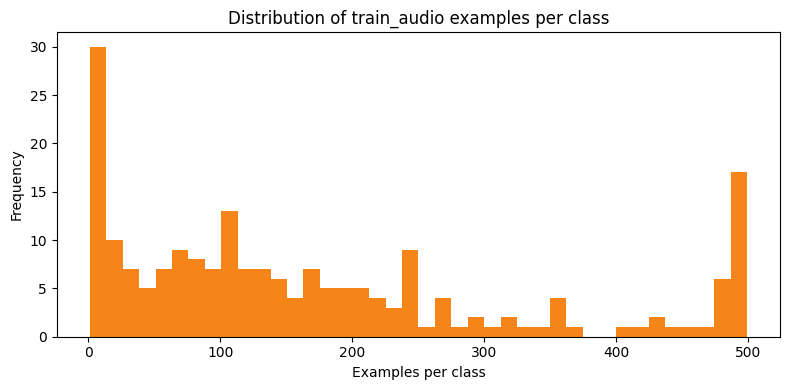

count    206.000000
mean     172.567961
std      155.371004
min        1.000000
25%       47.250000
50%      125.000000
75%      243.750000
max      499.000000
Name: count, dtype: float64

In [6]:
ax = label_counts.plot(kind="hist", bins=40, figsize=(8, 4), color="#F58518")
ax.set_title("Distribution of train_audio examples per class")
ax.set_xlabel("Examples per class")
plt.tight_layout()
plt.show()

label_counts.describe()

## 4. XC vs iNaturalist

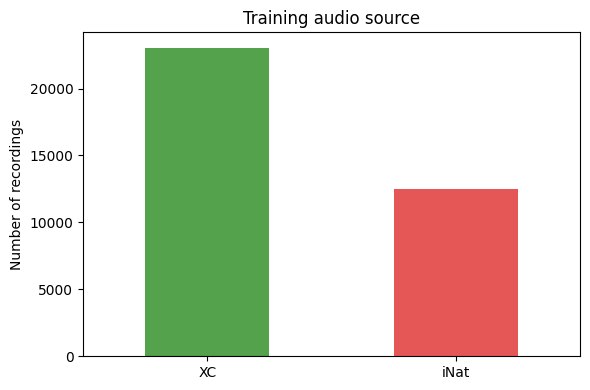

collection
XC      23043
iNat    12506
Name: count, dtype: int64

In [7]:
collection_counts = train["collection"].value_counts()

ax = collection_counts.plot(kind="bar", figsize=(6, 4), color=["#54A24B", "#E45756"])
ax.set_title("Training audio source")
ax.set_xlabel("")
ax.set_ylabel("Number of recordings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

collection_counts

## 5. Labeled train soundscapes

Эти данные ближе всего к hidden test: это реальные soundscape-записи, уже размеченные по 5-секундным сегментам.

In [8]:
exploded_soundscape = (
    soundscape_labels.assign(primary_label=soundscape_labels["primary_label"].astype(str).str.split(";"))
    .explode("primary_label")
)

soundscape_counts = exploded_soundscape["primary_label"].value_counts()

print(f"unique soundscape files: {soundscape_labels['filename'].nunique():,}")
print(f"unique soundscape labels: {soundscape_counts.size:,}")
soundscape_counts.head(25).to_frame("segments")

unique soundscape files: 66
unique soundscape labels: 75


,segments
primary_label,
65380,666
517063,626
22973,426
555146,420
23158,350
24279,346
24321,344
22967,310
66971,298


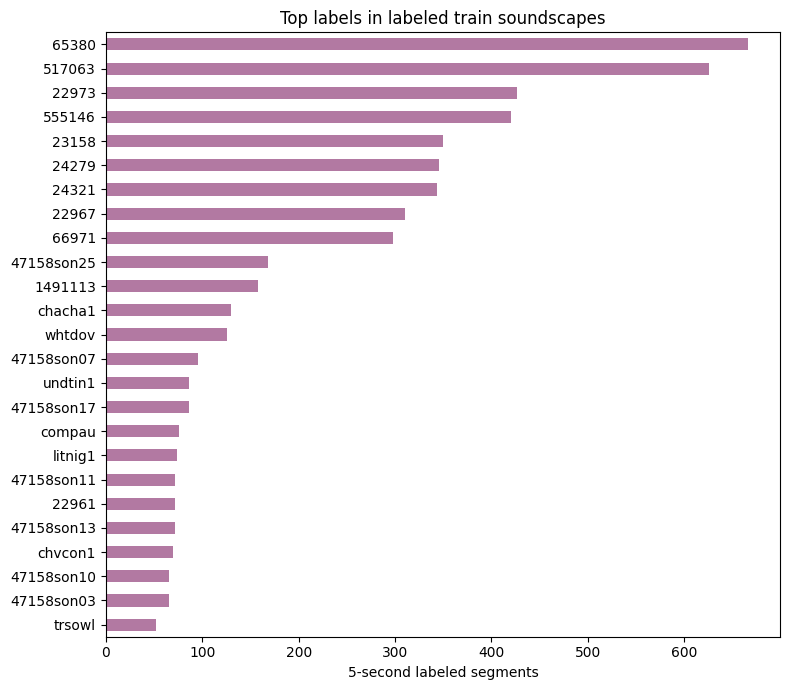

In [9]:
ax = soundscape_counts.head(25).sort_values().plot(kind="barh", figsize=(8, 7), color="#B279A2")
ax.set_title("Top labels in labeled train soundscapes")
ax.set_xlabel("5-second labeled segments")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 6. Какие классы есть только в soundscape-разметке

Это важная часть задания: некоторые классы hidden test могут быть представлены только в labeled soundscapes, а не в `train_audio`.

In [10]:
train_audio_labels = set(train["primary_label"].astype(str))
soundscape_label_set = set(exploded_soundscape["primary_label"].astype(str))
submission_labels = set(sample.columns[1:])

only_soundscape = sorted((soundscape_label_set - train_audio_labels) & submission_labels)
only_train_audio = sorted((train_audio_labels - soundscape_label_set) & submission_labels)
both_sources = sorted((train_audio_labels & soundscape_label_set) & submission_labels)

print(f"labels in both sources: {len(both_sources)}")
print(f"labels only in train_audio: {len(only_train_audio)}")
print(f"labels only in labeled soundscapes: {len(only_soundscape)}")

only_soundscape[:50]

labels in both sources: 47
labels only in train_audio: 159
labels only in labeled soundscapes: 28


['1491113',
 '25073',
 '47158son01',
 '47158son02',
 '47158son03',
 '47158son04',
 '47158son05',
 '47158son06',
 '47158son07',
 '47158son08',
 '47158son09',
 '47158son10',
 '47158son11',
 '47158son12',
 '47158son13',
 '47158son14',
 '47158son15',
 '47158son16',
 '47158son17',
 '47158son18',
 '47158son19',
 '47158son20',
 '47158son21',
 '47158son22',
 '47158son23',
 '47158son24',
 '47158son25',
 '517063']

## Выводы для модели

- Классы сильно несбалансированы.
- Soundscape-разметка маленькая, но очень ценная, потому что ближе к тестовым условиям.
- Простая модель нужна как baseline, но дальше нужно улучшать sampling, augmentations и архитектуру.
- Для отчета полезно показать графики выше и объяснить, почему задача multi-label: в одном 5-секундном сегменте может быть несколько видов.

## 7. Как аудио превращается в данные для модели

Модель не слушает звук как человек. Мы читаем `.ogg`, берем 5 секунд, затем превращаем сигнал в спектрограмму.

Спектрограмма похожа на картинку:

- по горизонтали время;
- по вертикали частоты;
- цвет показывает энергию звука.


In [11]:
import soundfile as sf
import torch
from IPython.display import Audio, display

sample_rate = 32_000


In [12]:
def read_audio_preview(path, start_seconds=0, duration=5, sr=32_000):
    audio, file_sr = sf.read(
        str(path),
        start=int(start_seconds * sr),
        frames=int(duration * sr),
        dtype="float32",
        always_2d=False,
    )
    if file_sr != sr:
        raise ValueError(f"Expected {sr} Hz, got {file_sr} Hz")
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    return audio


def make_log_spectrogram(audio, sr=32_000, n_fft=2048, hop_length=500):
    x = torch.from_numpy(audio)
    window = torch.hann_window(n_fft)
    spec = torch.stft(
        x,
        n_fft=n_fft,
        hop_length=hop_length,
        window=window,
        return_complex=True,
    ).abs().pow(2)
    return torch.log1p(spec).numpy()


def show_audio_example(path, start_seconds=0, title="Audio example"):
    audio = read_audio_preview(path, start_seconds=start_seconds)
    spec = make_log_spectrogram(audio)
    times = [i / sample_rate for i in range(len(audio))]

    print(path)
    display(Audio(audio, rate=sample_rate))

    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    axes[0].plot(times, audio, linewidth=0.6)
    axes[0].set_title(f"{title}: waveform")
    axes[0].set_xlabel("Seconds")
    axes[0].set_ylabel("Amplitude")

    axes[1].imshow(spec, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(f"{title}: log spectrogram")
    axes[1].set_xlabel("Time frames")
    axes[1].set_ylabel("Frequency bins")

    plt.tight_layout()
    plt.show()

    return audio, spec


### Пример из `train_audio`

Это короткая запись конкретного вида. Метка берется из `train.csv`.


label: 1161364
common_name: Guyalna cuta
/Users/kseniadragun/Desktop/Predictive_Analytics/birds /birdclef-2026/train_audio/1161364/iNat1216197.ogg


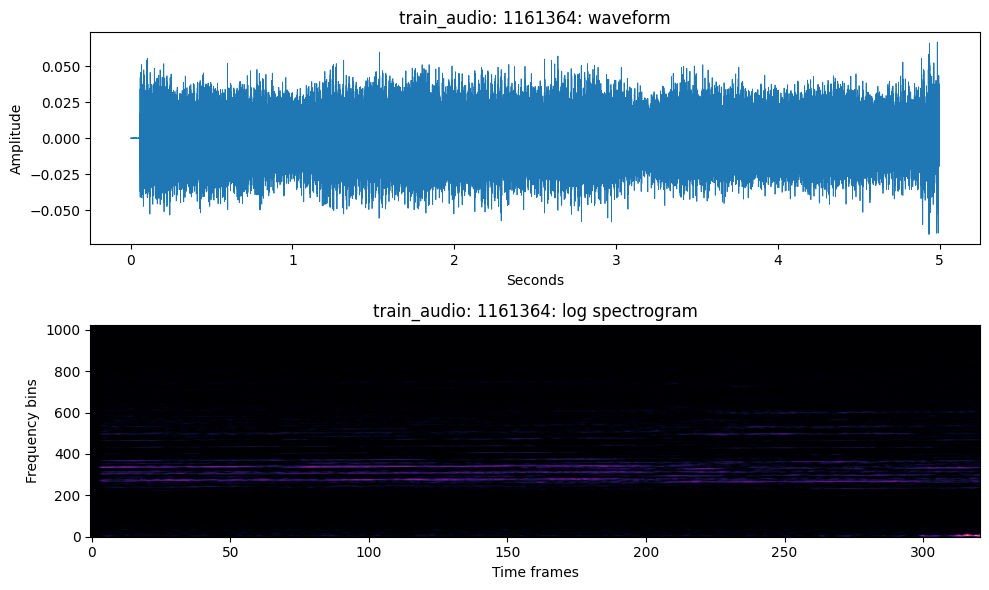

In [13]:
audio_row = train.iloc[0]
audio_path = data_dir / "train_audio" / audio_row["filename"]

print("label:", audio_row["primary_label"])
print("common_name:", audio_row.get("common_name", ""))

audio, spec = show_audio_example(
    audio_path,
    title=f"train_audio: {audio_row['primary_label']}"
)


### Пример из `train_soundscapes`

Это уже реальный 5-секундный кусок soundscape-записи. В одном сегменте может быть несколько видов, поэтому задача multi-label.


labels: 22961;23158;24321;517063;65380
segment: 00:00:00 to 00:00:05
/Users/kseniadragun/Desktop/Predictive_Analytics/birds /birdclef-2026/train_soundscapes/BC2026_Train_0039_S22_20211231_201500.ogg


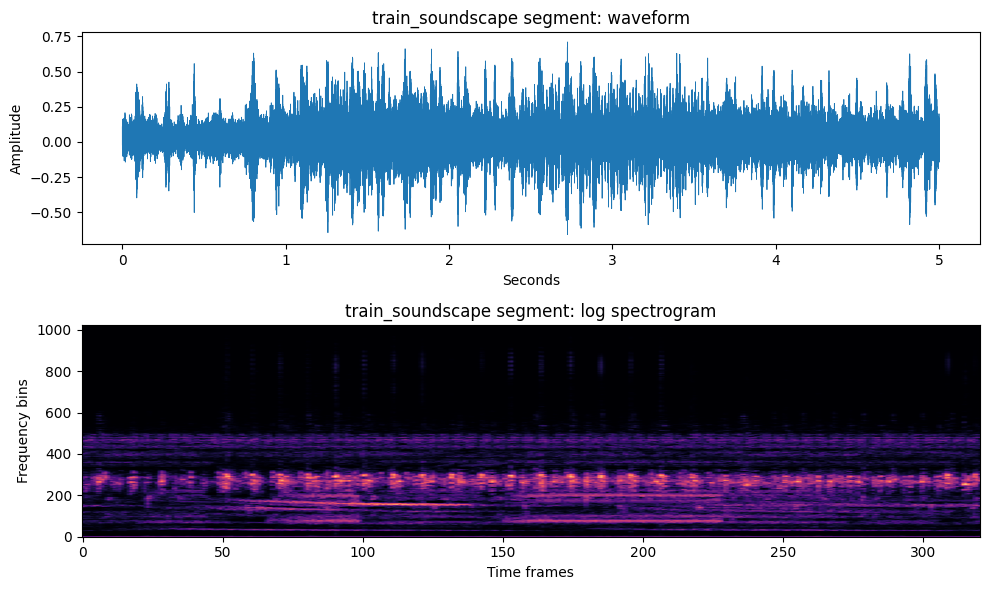

In [14]:
def time_to_seconds(value):
    parts = [float(part) for part in str(value).split(":")]
    seconds = 0.0
    for part in parts:
        seconds = seconds * 60 + part
    return seconds


soundscape_row = soundscape_labels.iloc[0]
soundscape_path = data_dir / "train_soundscapes" / soundscape_row["filename"]
start_seconds = time_to_seconds(soundscape_row["start"])

print("labels:", soundscape_row["primary_label"])
print("segment:", soundscape_row["start"], "to", soundscape_row["end"])

audio, spec = show_audio_example(
    soundscape_path,
    start_seconds=start_seconds,
    title="train_soundscape segment",
)


## 8. Comparing Spectrograms Across Classes


Теперь посмотрим несколько разных классов из `train_audio`.

Идея: разные виды часто имеют разные частотные паттерны.  
На спектрограммах это может выглядеть как разные полосы, импульсы, трели или короткие всплески.


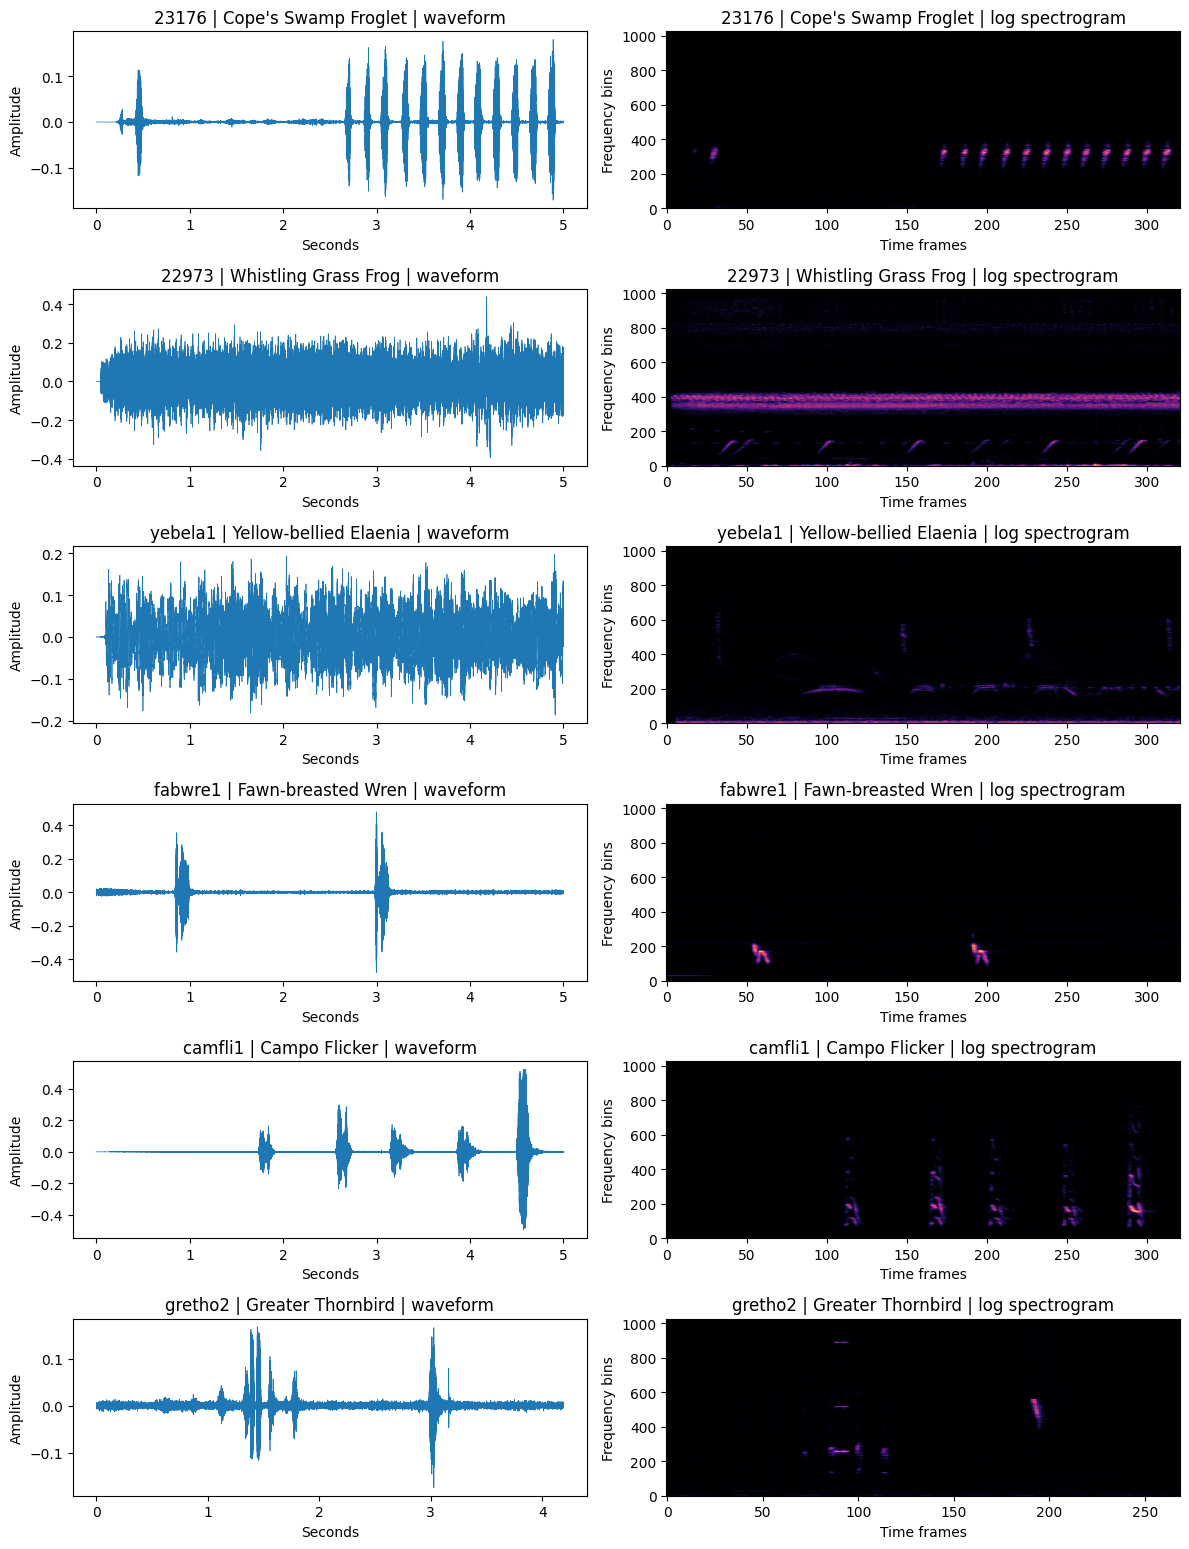

,primary_label,common_name,filename,collection,rating
0,23176,Cope's Swamp Froglet,23176/iNat1099971.ogg,iNat,0.0
1,22973,Whistling Grass Frog,22973/iNat28425.ogg,iNat,0.0
2,yebela1,Yellow-bellied Elaenia,yebela1/XC502910.ogg,XC,0.5
3,fabwre1,Fawn-breasted Wren,fabwre1/XC854900.ogg,XC,5.0
4,camfli1,Campo Flicker,camfli1/XC992878.ogg,XC,4.0
5,gretho2,Greater Thornbird,gretho2/iNat1673380.ogg,iNat,0.0


In [15]:
def show_multiple_train_audio_examples(train_df, n_examples=6):
    # Берем разные primary_label, чтобы не показать 6 записей одного и того же класса
    examples = (
        train_df
        .drop_duplicates("primary_label")
        .sample(n=n_examples, random_state=42)
        .reset_index(drop=True)
    )

    fig, axes = plt.subplots(n_examples, 2, figsize=(12, 2.6 * n_examples))

    if n_examples == 1:
        axes = [axes]

    for i, row in examples.iterrows():
        path = data_dir / "train_audio" / row["filename"]
        audio = read_audio_preview(path, start_seconds=0)
        spec = make_log_spectrogram(audio)

        label = row["primary_label"]
        common_name = row.get("common_name", "")

        times = [j / sample_rate for j in range(len(audio))]

        axes[i][0].plot(times, audio, linewidth=0.5)
        axes[i][0].set_title(f"{label} | {common_name} | waveform")
        axes[i][0].set_xlabel("Seconds")
        axes[i][0].set_ylabel("Amplitude")

        axes[i][1].imshow(spec, aspect="auto", origin="lower", cmap="magma")
        axes[i][1].set_title(f"{label} | {common_name} | log spectrogram")
        axes[i][1].set_xlabel("Time frames")
        axes[i][1].set_ylabel("Frequency bins")

    plt.tight_layout()
    plt.show()

    return examples[["primary_label", "common_name", "filename", "collection", "rating"]]


shown_examples = show_multiple_train_audio_examples(train, n_examples=6)
shown_examples


## 9. Audio Duration Analysis


Модель обучается на 5-секундных фрагментах, но исходные записи в `train_audio` могут быть короче или длиннее.

Это важно:

- если запись короче 5 секунд, мы дополняем её тишиной;
- если запись длиннее 5 секунд, мы берем 5-секундный кусок;
- слишком длинные записи можно использовать лучше, делая несколько random crops.


In [17]:
import soundfile as sf
from pathlib import Path

def get_audio_duration_seconds(path):
    info = sf.info(str(path))
    return info.frames / info.samplerate


duration_rows = []

# Для скорости сначала возьмем не все 35k файлов, а sample
duration_sample = train.sample(n=min(2000, len(train)), random_state=42).reset_index(drop=True)

for row in duration_sample.itertuples(index=False):
    path = data_dir / "train_audio" / row.filename
    try:
        duration_rows.append(
            {
                "primary_label": row.primary_label,
                "common_name": row.common_name,
                "filename": row.filename,
                "collection": row.collection,
                "rating": row.rating,
                "duration_sec": get_audio_duration_seconds(path),
            }
        )
    except Exception as e:
        duration_rows.append(
            {
                "primary_label": row.primary_label,
                "common_name": row.common_name,
                "filename": row.filename,
                "collection": row.collection,
                "rating": row.rating,
                "duration_sec": None,
                "error": str(e),
            }
        )

durations = pd.DataFrame(duration_rows)

durations.head()


,primary_label,common_name,filename,collection,rating,duration_sec
0,purjay1,Purplish Jay,purjay1/XC299441.ogg,XC,5.0,15.516000
1,saytan1,Sayaca Tanager,saytan1/iNat588079.ogg,iNat,0.0,8.661062
2,thlwre1,Thrush-like Wren,thlwre1/XC350961.ogg,XC,5.0,59.324094
3,whbwar2,White-browed Warbler,whbwar2/XC835399.ogg,XC,4.0,15.125031
4,whbwar2,White-browed Warbler,whbwar2/iNat502152.ogg,iNat,0.0,4.440000


count    2000.000000
mean       34.708566
std        73.037939
min         0.012000
25%        10.568695
50%        20.754281
75%        38.394000
max      2498.037000
Name: duration_sec, dtype: float64
Shorter than 5 seconds: 8.4%
At least 5 seconds: 91.6%


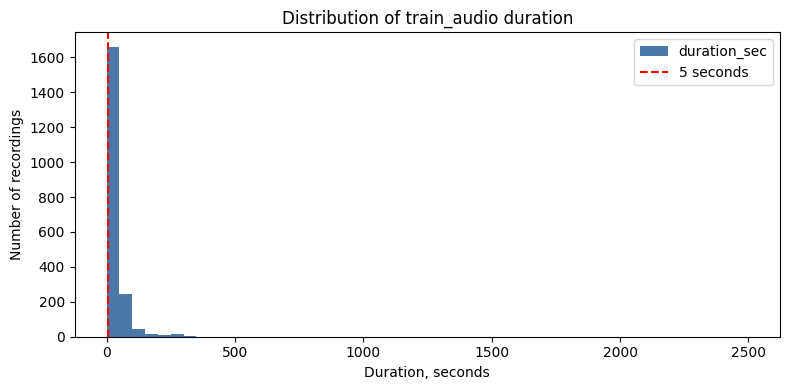

In [18]:
print(durations["duration_sec"].describe())

shorter_than_5 = (durations["duration_sec"] < 5).mean()
longer_than_5 = (durations["duration_sec"] >= 5).mean()

print(f"Shorter than 5 seconds: {shorter_than_5:.1%}")
print(f"At least 5 seconds: {longer_than_5:.1%}")

ax = durations["duration_sec"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    color="#4C78A8",
)

ax.axvline(5, color="red", linestyle="--", label="5 seconds")
ax.set_title("Distribution of train_audio duration")
ax.set_xlabel("Duration, seconds")
ax.set_ylabel("Number of recordings")
ax.legend()

plt.tight_layout()
plt.show()



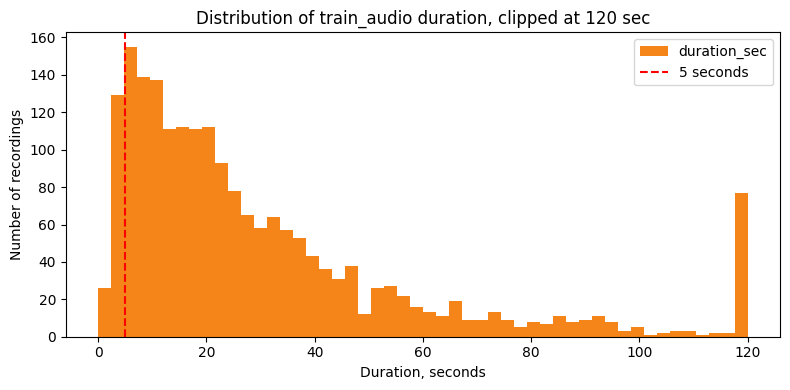

In [19]:
ax = durations["duration_sec"].clip(upper=120).plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    color="#F58518",
)

ax.axvline(5, color="red", linestyle="--", label="5 seconds")
ax.set_title("Distribution of train_audio duration, clipped at 120 sec")
ax.set_xlabel("Duration, seconds")
ax.set_ylabel("Number of recordings")
ax.legend()

plt.tight_layout()
plt.show()


Most train_audio recordings are longer than the 5-second model input window, so random 5-second cropping is a reasonable preprocessing strategy. Shorter recordings require zero-padding.


### Interpretation: audio duration

Most `train_audio` recordings are longer than the 5-second input window used by the model.

This is important for preprocessing:

- recordings shorter than 5 seconds need zero-padding;
- recordings longer than 5 seconds can be randomly cropped during training;
- random 5-second crops help the model see different parts of the same recording across epochs;
- this is useful because a long recording may contain silence, noise, or multiple vocalization events.

In our 2,000-file sample, about 91.6% of recordings are at least 5 seconds long, while about 8.4% are shorter than 5 seconds.



### Key takeaway

The 5-second segmentation strategy is compatible with the dataset because most training recordings are longer than 5 seconds.  
For long recordings, random cropping can increase training diversity.  
For short recordings, zero-padding keeps the input size consistent.
